In [21]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import sys
import os
import pickle
import json
import numpy as np
import seaborn as sns
import random
import matplotlib.pyplot as plt 
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score
from torch.utils.data import  Subset
from torch_geometric.loader import DataLoader
from tqdm import tqdm
import pandas as pd
from networks import GAT, PPGAT


In [22]:
#set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True


In [23]:
with open('datasets/df_random_vs_st_dataset_revised.pkl', 'rb') as f:
    data = pickle.load(f)

In [24]:
targets = data['accession'].unique()
targets

array(['P08581', 'P35968', 'Q16790', 'P56817', 'P22303', 'P06276',
       'P00915', 'P34913', 'Q13547', 'P27487'], dtype=object)

In [25]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for data in dataloader:
            data = data.to(device)
            out = model(data)
            probs = torch.sigmoid(out).view(-1).cpu().numpy()
            labels = data.y.view(-1).cpu().numpy()

            # Ensure probs and labels are arrays, even for batch size 1
            probs = np.atleast_1d(probs)
            labels = np.atleast_1d(labels)

            all_probs.extend(probs)
            all_labels.extend(labels)

    y_pred = (np.array(all_probs) > 0.5).astype(int)
    acc = accuracy_score(all_labels, y_pred)
    auroc = roc_auc_score(all_labels, all_probs)
    return acc, auroc



In [26]:
k_folds = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = {}
for target in targets:
    print(f"\nTarget: {target} ")

    # Load datasets
    dataset_gat = torch.load(f"datasets/Gdatasets/{target}_dataset.pt", weights_only=False)
    dataset_rg = torch.load(f"datasets/RGdatasets/{target}_RG_dataset.pt", weights_only=False)
    dataset_ppgat = torch.load(f"datasets/PPGATdatasets/{target}_PPGAT_dataset.pt", weights_only=False)

    # Define models and configs
    model_info = {
        "GAT": (GAT, dataset_gat, f"results/models/gat/{target}/best_config.json"),
        "GAT-rg": (GAT, dataset_rg, f"results/models/gat_rg/{target}/best_config.json"),
        "PPGAT": (PPGAT, dataset_ppgat, f"results/models/ppgat/{target}/best_config.json"),
    }

    target_results = {}

    for model_name, (model_class, dataset, config_path) in model_info.items():
        print(f"\n Evaluating {model_name}")

        # Load config
        with open(config_path, "r") as f:
            best_config = json.load(f)

        lr = best_config["lr"]
        batch_size = best_config["batch_size"]
    
        print(f"Loaded config: {best_config}")

        labels = np.array([data.y.item() for data in dataset])
        skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

        acc_scores, auroc_scores = [], []

        # Stratified K-Fold loop
        
        for fold, (train_idx, test_idx) in enumerate(
            skf.split(np.zeros(len(labels)), labels)
        ):
            print(f"\n{model_name} | Fold {fold + 1}/{k_folds}")

            train_subset = Subset(dataset, train_idx)
            test_subset = Subset(dataset, test_idx)

            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

            in_channels = dataset[0].x.shape[1]
            edge_attr_dim = dataset[0].edge_attr.shape[1] if hasattr(dataset[0], "edge_attr") else 0
            out_channels = 1  

            hidden_channels = best_config.get("hidden_channels", 32)

            model = model_class(
                in_channels=in_channels,
                edge_attr_dim=edge_attr_dim,
                hidden_channels=hidden_channels,
                out_channels=out_channels,
                **best_config.get("model_params", {})
            ).to(device)

            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = torch.nn.BCEWithLogitsLoss()

            # Training loop
            model.train()

            epochs = 100
            for epoch in range(epochs):
                total_loss = 0
                for batch in train_loader:
                    batch = batch.to(device)
                    optimizer.zero_grad()
                    out = model(batch)
                    loss = criterion(out.view(-1), batch.y.float())
                    loss.backward()
                    optimizer.step()
                    total_loss += loss.item() * batch.num_graphs

                if (epoch + 1) % max(1, epochs // 5) == 0:
                    avg_loss = total_loss / len(train_loader.dataset)
                    print(f"Epoch {epoch + 1:03d}/{epochs}: Loss={avg_loss:.4f}")

            
            # Evaluation on test fold
            
            acc, auroc = evaluate_model(model, test_loader, device)
            acc_scores.append(acc)
            auroc_scores.append(auroc)

            print(f"Fold {fold + 1} Results → Accuracy: {acc:.4f}, AUROC: {auroc:.4f}")

    
        #  results
        acc_mean, acc_std = np.mean(acc_scores), np.std(acc_scores)
        auroc_mean, auroc_std = np.mean(auroc_scores), np.std(auroc_scores)

        target_results[model_name] = {
            "Accuracy": f"{acc_mean:.3f} ± {acc_std:.3f}",
            "AUROC": f"{auroc_mean:.3f} ± {auroc_std:.3f}",
        }

        print(
            f"\n{model_name} Mean Performance on {target}: "
            f"Accuracy = {acc_mean:.3f} ± {acc_std:.3f}, "
            f"AUROC = {auroc_mean:.3f} ± {auroc_std:.3f}"
        )

    # Store results for target
    results[target] = target_results

# Save Summary
df = pd.DataFrame(results).T
print("\n Final Cross-Validation Results ")
print(df)
df.to_csv("crossval_results.csv", index=True)


Target: P08581 

 Evaluating GAT
Loaded config: {'lr': 0.001, 'batch_size': 16}

GAT | Fold 1/5
Epoch 020/100: Loss=0.1825
Epoch 040/100: Loss=0.1033
Epoch 060/100: Loss=0.0782
Epoch 080/100: Loss=0.0362
Epoch 100/100: Loss=0.0289
Fold 1 Results → Accuracy: 0.9488, AUROC: 0.9751

GAT | Fold 2/5
Epoch 020/100: Loss=0.2202
Epoch 040/100: Loss=0.1215
Epoch 060/100: Loss=0.1093
Epoch 080/100: Loss=0.0580
Epoch 100/100: Loss=0.0371
Fold 2 Results → Accuracy: 0.9223, AUROC: 0.9681

GAT | Fold 3/5
Epoch 020/100: Loss=0.1644
Epoch 040/100: Loss=0.0946
Epoch 060/100: Loss=0.0608
Epoch 080/100: Loss=0.0288
Epoch 100/100: Loss=0.0245
Fold 3 Results → Accuracy: 0.9505, AUROC: 0.9807

GAT | Fold 4/5
Epoch 020/100: Loss=0.1777
Epoch 040/100: Loss=0.1111
Epoch 060/100: Loss=0.0661
Epoch 080/100: Loss=0.0595
Epoch 100/100: Loss=0.0266
Fold 4 Results → Accuracy: 0.9540, AUROC: 0.9792

GAT | Fold 5/5
Epoch 020/100: Loss=0.1804
Epoch 040/100: Loss=0.1017
Epoch 060/100: Loss=0.0936
Epoch 080/100: Loss=0.

In [7]:
df

,GAT,GAT-rg,PPGAT
P08581,"{'Accuracy': '0.942 ± 0.004', 'AUROC': '0.978 ...","{'Accuracy': '0.911 ± 0.021', 'AUROC': '0.959 ...","{'Accuracy': '0.901 ± 0.007', 'AUROC': '0.959 ..."
P35968,"{'Accuracy': '0.893 ± 0.006', 'AUROC': '0.951 ...","{'Accuracy': '0.877 ± 0.011', 'AUROC': '0.936 ...","{'Accuracy': '0.874 ± 0.008', 'AUROC': '0.939 ..."
Q16790,"{'Accuracy': '0.970 ± 0.002', 'AUROC': '0.989 ...","{'Accuracy': '0.959 ± 0.003', 'AUROC': '0.984 ...","{'Accuracy': '0.965 ± 0.003', 'AUROC': '0.986 ..."
P56817,"{'Accuracy': '0.927 ± 0.012', 'AUROC': '0.977 ...","{'Accuracy': '0.918 ± 0.009', 'AUROC': '0.968 ...","{'Accuracy': '0.932 ± 0.006', 'AUROC': '0.980 ..."
P22303,"{'Accuracy': '0.912 ± 0.007', 'AUROC': '0.962 ...","{'Accuracy': '0.907 ± 0.013', 'AUROC': '0.958 ...","{'Accuracy': '0.903 ± 0.016', 'AUROC': '0.959 ..."
P06276,"{'Accuracy': '0.913 ± 0.016', 'AUROC': '0.963 ...","{'Accuracy': '0.894 ± 0.015', 'AUROC': '0.941 ...","{'Accuracy': '0.903 ± 0.012', 'AUROC': '0.956 ..."
P00915,"{'Accuracy': '0.967 ± 0.001', 'AUROC': '0.988 ...","{'Accuracy': '0.955 ± 0.006', 'AUROC': '0.983 ...","{'Accuracy': '0.967 ± 0.005', 'AUROC': '0.987 ..."
P34913,"{'Accuracy': '0.945 ± 0.012', 'AUROC': '0.982 ...","{'Accuracy': '0.943 ± 0.005', 'AUROC': '0.975 ...","{'Accuracy': '0.944 ± 0.007', 'AUROC': '0.982 ..."
Q13547,"{'Accuracy': '0.978 ± 0.004', 'AUROC': '0.985 ...","{'Accuracy': '0.964 ± 0.002', 'AUROC': '0.984 ...","{'Accuracy': '0.964 ± 0.005', 'AUROC': '0.985 ..."
P27487,"{'Accuracy': '0.969 ± 0.006', 'AUROC': '0.992 ...","{'Accuracy': '0.969 ± 0.002', 'AUROC': '0.987 ...","{'Accuracy': '0.974 ± 0.005', 'AUROC': '0.990 ..."


In [8]:

records=[]
for target in df.index:
    for model in df.columns:
        cell = df.loc[target, model]
        if isinstance(cell, dict):
            auroc_str = cell.get("AUROC", "0 ± 0")
            acc_str = cell.get("Accuracy", "0 ± 0")

            auroc_mean, auroc_std = auroc_str.split("±")
            acc_mean, acc_std = acc_str.split("±")


            records.append({
                "Target": target,
                "Model": model,
                "AUROC_mean": float(auroc_mean),
                "AUROC_std": float(auroc_std),
                "Accuracy_mean" : float(acc_mean),
                "Accuracy_std": float(acc_std)
            })

df_flat = pd.DataFrame(records)
print(df_flat)

    Target   Model  AUROC_mean  AUROC_std  Accuracy_mean  Accuracy_std
0   P08581     GAT       0.978      0.003          0.942         0.004
1   P08581  GAT-rg       0.959      0.008          0.911         0.021
2   P08581   PPGAT       0.959      0.007          0.901         0.007
3   P35968     GAT       0.951      0.004          0.893         0.006
4   P35968  GAT-rg       0.936      0.011          0.877         0.011
5   P35968   PPGAT       0.939      0.008          0.874         0.008
6   Q16790     GAT       0.989      0.002          0.970         0.002
7   Q16790  GAT-rg       0.984      0.004          0.959         0.003
8   Q16790   PPGAT       0.986      0.002          0.965         0.003
9   P56817     GAT       0.977      0.007          0.927         0.012
10  P56817  GAT-rg       0.968      0.005          0.918         0.009
11  P56817   PPGAT       0.980      0.004          0.932         0.006
12  P22303     GAT       0.962      0.008          0.912         0.007
13  P2

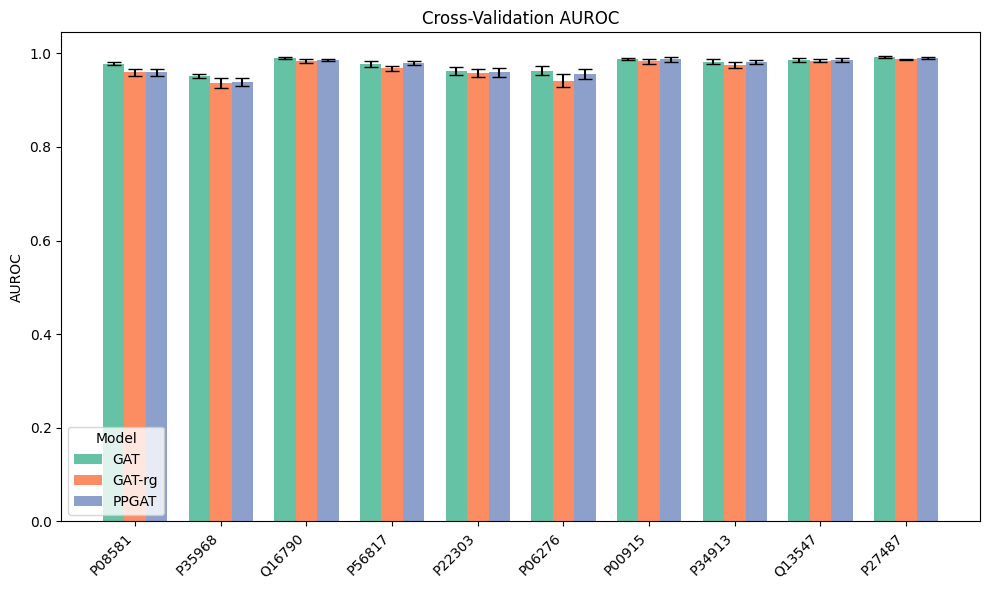

In [11]:
# plot cross validation results 


colors=sns.color_palette("Set2")

targets = df_flat["Target"].unique()
models = df_flat["Model"].unique()
x = np.arange(len(targets))
width = 0.25

plt.figure(figsize=(10, 6))

for i, model in enumerate(models):
    subset = df_flat[df_flat["Model"] == model]
    plt.bar(
        x + i * width,
        subset["AUROC_mean"],
        width,
        label=model,
        yerr=subset["AUROC_std"],
        capsize=5,
        color=colors[i]
    )

plt.xticks(x + width, targets, rotation=45, ha="right")
plt.ylabel("AUROC")
plt.title("Cross-Validation AUROC")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

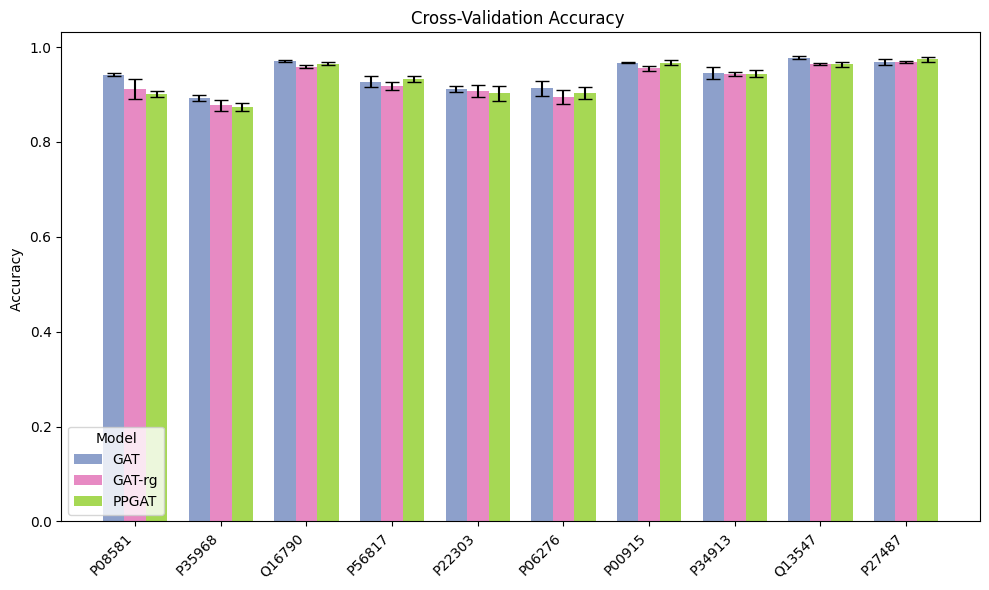

In [12]:

colors=sns.color_palette("Set2")

targets = df_flat["Target"].unique()
models = df_flat["Model"].unique()
x = np.arange(len(targets))
width = 0.25

plt.figure(figsize=(10, 6))

for i, model in enumerate(models):
    subset = df_flat[df_flat["Model"] == model]
    plt.bar(
        x + i * width,
        subset["Accuracy_mean"],
        width,
        label=model,
        yerr=subset["Accuracy_std"],
        capsize=5,
        color=colors[i+2]
    )

plt.xticks(x + width, targets, rotation=45, ha="right")
plt.ylabel("Accuracy ")
plt.title("Cross-Validation Accuracy ")
plt.legend(title="Model")
plt.tight_layout()
plt.show()